In [135]:
# Dependencies and Setup
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd
import scipy.stats as st
import numpy as np

# Study data files
mouse_metadata_path = "data/Mouse_metadata.csv"
study_results_path = "data/Study_results.csv"

# Read the mouse data and the study results
mouse_metadata = pd.read_csv(mouse_metadata_path)
study_results = pd.read_csv(study_results_path)

# Combine the data into a single DataFrame
mousestudy_df = pd.merge(mouse_metadata, study_results, on="Mouse ID")

# Display the data table for preview
mousestudy_df

,Mouse ID,Drug Regimen,Sex,Age_months,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites
0,k403,Ramicane,Male,21,16,0,45.000000,0
1,k403,Ramicane,Male,21,16,5,38.825898,0
2,k403,Ramicane,Male,21,16,10,35.014271,1
3,k403,Ramicane,Male,21,16,15,34.223992,1
4,k403,Ramicane,Male,21,16,20,32.997729,1
...,...,...,...,...,...,...,...,...
1888,z969,Naftisol,Male,9,30,25,63.145652,2
1889,z969,Naftisol,Male,9,30,30,65.841013,3
1890,z969,Naftisol,Male,9,30,35,69.176246,4
1891,z969,Naftisol,Male,9,30,40,70.314904,4


In [136]:
# Checking the number of mice.
unique = mousestudy_df["Mouse ID"].unique()
len(unique)

249

In [137]:
# Our data should be uniquely identified by Mouse ID and Timepoint
# Get the duplicate mice by ID number that shows up for Mouse ID and Timepoint.
mousestudy_df[mousestudy_df.duplicated(["Mouse ID", "Timepoint"], keep=False)]

,Mouse ID,Drug Regimen,Sex,Age_months,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites
908,g989,Propriva,Female,21,26,0,45.000000,0
909,g989,Propriva,Female,21,26,0,45.000000,0
910,g989,Propriva,Female,21,26,5,48.786801,0
911,g989,Propriva,Female,21,26,5,47.570392,0
912,g989,Propriva,Female,21,26,10,51.745156,0
913,g989,Propriva,Female,21,26,10,49.880528,0
914,g989,Propriva,Female,21,26,15,51.325852,1
915,g989,Propriva,Female,21,26,15,53.442020,0
916,g989,Propriva,Female,21,26,20,55.326122,1
917,g989,Propriva,Female,21,26,20,54.657650,1


In [138]:
# Create a clean DataFrame by dropping the duplicate mouse by its ID.
# https://stackoverflow.com/questions/18172851/deleting-dataframe-row-in-pandas-based-on-column-value
cleaned_df = mousestudy_df[mousestudy_df["Mouse ID"] != "g989"]
cleaned_df

,Mouse ID,Drug Regimen,Sex,Age_months,Weight (g),Timepoint,Tumor Volume (mm3),Metastatic Sites
0,k403,Ramicane,Male,21,16,0,45.000000,0
1,k403,Ramicane,Male,21,16,5,38.825898,0
2,k403,Ramicane,Male,21,16,10,35.014271,1
3,k403,Ramicane,Male,21,16,15,34.223992,1
4,k403,Ramicane,Male,21,16,20,32.997729,1
...,...,...,...,...,...,...,...,...
1888,z969,Naftisol,Male,9,30,25,63.145652,2
1889,z969,Naftisol,Male,9,30,30,65.841013,3
1890,z969,Naftisol,Male,9,30,35,69.176246,4
1891,z969,Naftisol,Male,9,30,40,70.314904,4


In [139]:
# Checking the number of mice in the clean DataFrame.
unique_clean = cleaned_df["Mouse ID"].unique()
len(unique_clean)

248

## Summary Statistics

In [140]:
# Generate a summary statistics table of mean, median, variance, standard deviation, and SEM of the tumor volume for each regimen
cleaned_mean = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].mean()
cleaned_median = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].median()
cleaned_variance = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].var()
cleaned_std = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].std()
cleaned_sem = cleaned_df.groupby(["Drug Regimen"])["Tumor Volume (mm3)"].sem()
# Use groupby and summary statistical methods to calculate the following properties of each drug regimen:
# mean, median, variance, standard deviation, and SEM of the tumor volume.
# Assemble the resulting series into a single summary DataFrame.
summary_df = pd.DataFrame()
summary_df["Tumor Volume Mean"] = cleaned_mean
summary_df["Tumor Volume Median"] = cleaned_median
summary_df["Tumor Volume Varaince"] = cleaned_variance
summary_df["Tumor Volume Standard Deviation"] = cleaned_std
summary_df["Tumor Volume SEM"] = cleaned_sem

summary_df

,Tumor Volume Mean,Tumor Volume Median,Tumor Volume Varaince,Tumor Volume Standard Deviation,Tumor Volume SEM
Drug Regimen,,,,,
Capomulin,40.675741,41.557809,24.947764,4.994774,0.329346
Ceftamin,52.591172,51.776157,39.290177,6.268188,0.469821
Infubinol,52.884795,51.820584,43.128684,6.567243,0.492236
Ketapril,55.235638,53.698743,68.553577,8.279709,0.603860
Naftisol,54.331565,52.509285,66.173479,8.134708,0.596466
Placebo,54.033581,52.288934,61.168083,7.821003,0.581331
Propriva,52.320930,50.446266,43.852013,6.622085,0.544332
Ramicane,40.216745,40.673236,23.486704,4.846308,0.320955
Stelasyn,54.233149,52.431737,59.450562,7.710419,0.573111


## Bar and Pie Charts

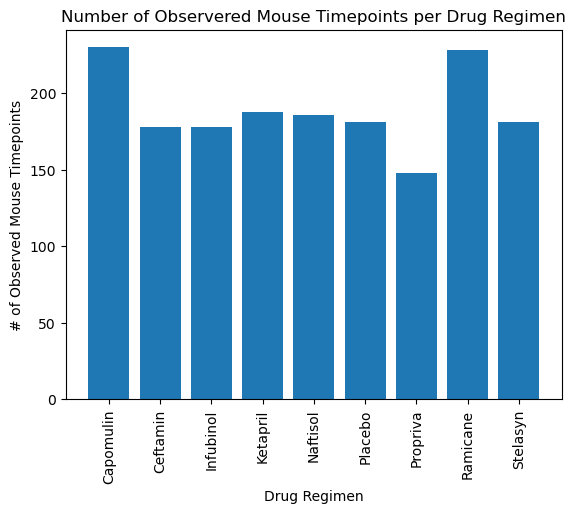

In [141]:
# Generate a bar plot showing the total number of rows (Mouse ID/Timepoints) for each drug regimen using pyplot.
#Drug Count = len(cleaned_df[cleaned_df["Drug Regimen"] == "Drug Name"])
Ca = len(cleaned_df[cleaned_df["Drug Regimen"] == "Capomulin"])
Ce = len(cleaned_df[cleaned_df["Drug Regimen"] == "Ceftamin"])
I = len(cleaned_df[cleaned_df["Drug Regimen"] == "Infubinol"])
K = len(cleaned_df[cleaned_df["Drug Regimen"] == "Ketapril"])
N = len(cleaned_df[cleaned_df["Drug Regimen"] == "Naftisol"])
Pl = len(cleaned_df[cleaned_df["Drug Regimen"] == "Placebo"])
Pr = len(cleaned_df[cleaned_df["Drug Regimen"] == "Propriva"])
R = len(cleaned_df[cleaned_df["Drug Regimen"] == "Ramicane"])
S = len(cleaned_df[cleaned_df["Drug Regimen"] == "Stelasyn"])

x_data = ["Capomulin", "Ceftamin", "Infubinol", "Ketapril", "Naftisol", "Placebo", "Propriva", "Ramicane", "Stelasyn"]
y_data = [Ca, Ce, I, K, N, Pl, Pr, R, S]

plt.bar(x_data, y_data)
plt.xlabel("Drug Regimen")
plt.xticks(rotation=90)
plt.ylabel("# of Observed Mouse Timepoints")
plt.title("Number of Observered Mouse Timepoints per Drug Regimen")
plt.show()

<BarContainer object of 9 artists>

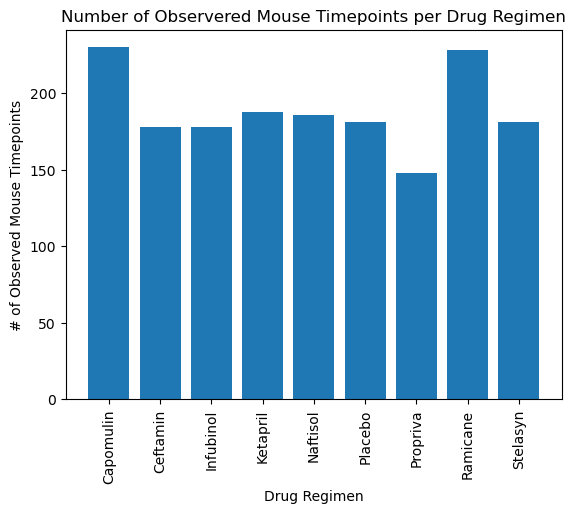

In [142]:
# Generate a bar plot showing the total number of rows (Mouse ID/Timepoints) for each drug regimen using Pandas.
cleaned_df[cleaned_df.groupby(["Drug Regimen"]).sum()].plot(legend=False, rot=90, xlabel="Drug Regimen", ylabel="# of Observed Mouse Timepoints", title="Number of Observered Mouse Timepoints per Drug Regimen").bar(x_data, y_data)

array([<Axes: ylabel='count'>], dtype=object)

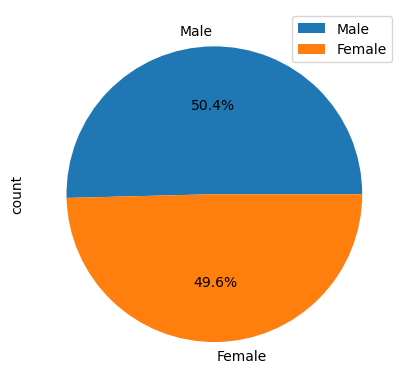

In [143]:
# Generate a pie chart, using Pandas, showing the distribution of unique female versus male mice used in the study

# Get the unique mice with their gender
male = len(cleaned_df[cleaned_df["Sex"] == "Male"]["Mouse ID"].unique())
female = len(cleaned_df[cleaned_df["Sex"] == "Female"]["Mouse ID"].unique())

# Make the pie chart
unique_mouse_gender_pie_chart_df = pd.DataFrame([male, female], index=["Male", "Female"], columns = ["count"])
unique_mouse_gender_pie_chart_df.plot(kind="pie", subplots=True, autopct="%1.1f%%")

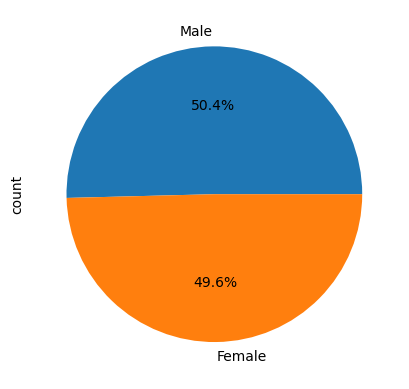

In [144]:
# Generate a pie chart, using pyplot, showing the distribution of unique female versus male mice used in the study

# Get the unique mice with their gender
data = [male, female]
labels= ["Male", "Female"]

# Make the pie chart
plt.pie(data, autopct="%1.1f%%", labels=labels)
plt.ylabel("count")
plt.show()


## Quartiles, Outliers and Boxplots

In [145]:
# Calculate the final tumor volume of each mouse across four of the treatment regimens:  
# Capomulin, Ramicane, Infubinol, and Ceftamin
# Start by getting the last (greatest) timepoint for each mouse
cleaned_df = pd.DataFrame(cleaned_df)
print(cleaned_df)



     Mouse ID Drug Regimen   Sex  Age_months  Weight (g)  Timepoint  \
0        k403     Ramicane  Male          21          16          0   
1        k403     Ramicane  Male          21          16          5   
2        k403     Ramicane  Male          21          16         10   
3        k403     Ramicane  Male          21          16         15   
4        k403     Ramicane  Male          21          16         20   
...       ...          ...   ...         ...         ...        ...   
1888     z969     Naftisol  Male           9          30         25   
1889     z969     Naftisol  Male           9          30         30   
1890     z969     Naftisol  Male           9          30         35   
1891     z969     Naftisol  Male           9          30         40   
1892     z969     Naftisol  Male           9          30         45   

      Tumor Volume (mm3)  Metastatic Sites  
0              45.000000                 0  
1              38.825898                 0  
2           

In [146]:
last_timepoints = cleaned_df.groupby("Mouse ID")["Timepoint"].max().reset_index()
print(last_timepoints)

    Mouse ID  Timepoint
0       a203         45
1       a251         45
2       a262         45
3       a275         45
4       a366         30
..       ...        ...
243     z435         10
244     z578         45
245     z581         45
246     z795         45
247     z969         45

[248 rows x 2 columns]


In [147]:
# Merge this group df with the original dataframe to get the tumor volume at the last timepoint
merged_df = pd.merge(cleaned_df, last_timepoints, how="inner", on=["Mouse ID", "Timepoint"])
print(merged_df)

    Mouse ID Drug Regimen     Sex  Age_months  Weight (g)  Timepoint  \
0       k403     Ramicane    Male          21          16         45   
1       s185    Capomulin  Female           3          17         45   
2       x401    Capomulin  Female          16          15         45   
3       m601    Capomulin    Male          22          17         45   
4       g791     Ramicane    Male          11          16         45   
..       ...          ...     ...         ...         ...        ...   
243     z314     Stelasyn  Female          21          28          5   
244     z435     Propriva  Female          12          26         10   
245     z581    Infubinol  Female          24          25         45   
246     z795     Naftisol  Female          13          29         45   
247     z969     Naftisol    Male           9          30         45   

     Tumor Volume (mm3)  Metastatic Sites  
0             22.050126                 1  
1             23.343598                 1  
2  

In [148]:
# Put treatments into a list for for loop (and later for plot labels)
treatment = pd.DataFrame(cleaned_df)
treatment = cleaned_df["Drug Regimen"].unique().tolist()
for treatment in treatment:
    print("processing data for {treatment")

processing data for {treatment
processing data for {treatment
processing data for {treatment
processing data for {treatment
processing data for {treatment
processing data for {treatment
processing data for {treatment
processing data for {treatment
processing data for {treatment
processing data for {treatment


In [149]:

# Create empty list to fill with tumor vol data (for plotting)tumor
capomulin_data = []
ramicane_data = []
infubinol_data = []
ceftamin_data = []

# Locate the rows which contain mice on each drug and get the tumour volumes
for index, row in cleaned_df.iterrows():
    if row["Drug Regimen"] == treatment[0]:
        capomulin_data.append(row['Tumour Volume (mm3)'])
    if row["Drug Regimen"] == treatment[1]:
        ramicane_data.append(row['Tumour Volume (mm3)'])
    if row["Drug Regimen"] == treatment[2]:
        infubinol_data.append(row['Tumour Volume (mm3)'])
    if row["Drug Regimen"] == treatment[3]:
        ceftamin_data.append(row['Tumour Volume (mm3)'])      

# Add to new DF
cleaned_df = pd.DataFrame({treatment[0]: capomulin_data,
                       treatment[1]: ramicane_data,
                       treatment[2]: infubinol_data,
                       treatment[3]: ceftamin_data
                       })

cleaned_df.head()




    

,N,a,f,t


In [150]:
# Calculate the IQR and quantitatively determine if there are any potential outliers.
# Group by "Drug Regimen"
df = mousestudy_df

# Dictionary to store outliers
outliers_dict ={}

# list to store rsults
tumor_volume_results = []

# iterate over each "Drug Regimen"
for drug, data in df.groupby('Drug Regimen')["Tumor Volume (mm3)"]:

# Calculate quartiles and IQR

    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1

# Determine outliers using upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR 

# Identify potential outliers

outliers = data[(data < lower_bound) | data > (upper_bound)].tolist()
outliers_dict[drug] = outliers

# Append result to list
tumor_volume_results.append({"Drug Regimen": drug, "Tumor Volume Data": data.tolist(), "Q1": Q1, "Q3": Q3, "IQR": IQR,
"Lower Bound": lower_bound, "Upper Bound": upper_bound,
"Outliers": outliers})

# Convert resulst to a DataFrame
tumor_volume_df = pd.DataFrame(tumor_volume_results)

# print results
print("Tumor Volume Data For Each Drug:\n",tumor_volume_df)
print("\nIdentified Outliers;\n", outliers_dict)



Tumor Volume Data For Each Drug:
   Drug Regimen                                  Tumor Volume Data         Q1  \
0    Zoniferol  [45.0, 46.11198591, 47.7259374, 49.93472542, 5...  47.337876   

          Q3        IQR  Lower Bound  Upper Bound Outliers  
0  57.954259  10.616383    31.413302    73.878833       []  

Identified Outliers;
 {'Zoniferol': []}


/var/folders/3l/qnm5hprx4z76qvd5ygknmsvr0000gn/T/ipykernel_22355/3245003870.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Drug Regimen", y="Tumor Volume (mm3)", data=mousestudy_df, palette="Set2")


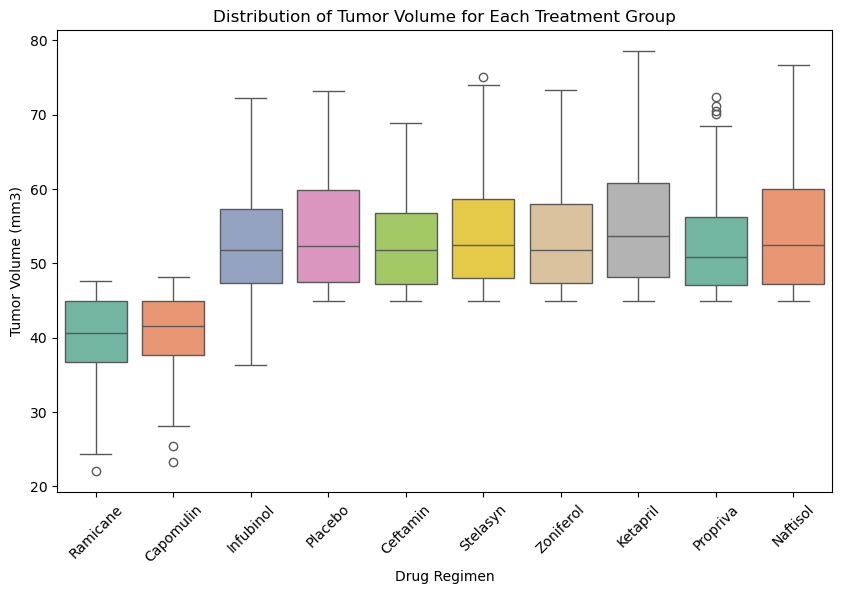

In [151]:
# Generate a box plot that shows the distribution of the tumor volume for each treatment group.
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 6))

# Create box plot
sns.boxplot(x="Drug Regimen", y="Tumor Volume (mm3)", data=mousestudy_df, palette="Set2")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add labels and title
plt.xlabel("Drug Regimen")
plt.ylabel("Tumor Volume (mm3)")
plt.title("Distribution of Tumor Volume for Each Treatment Group")

# Show plot
plt.show()

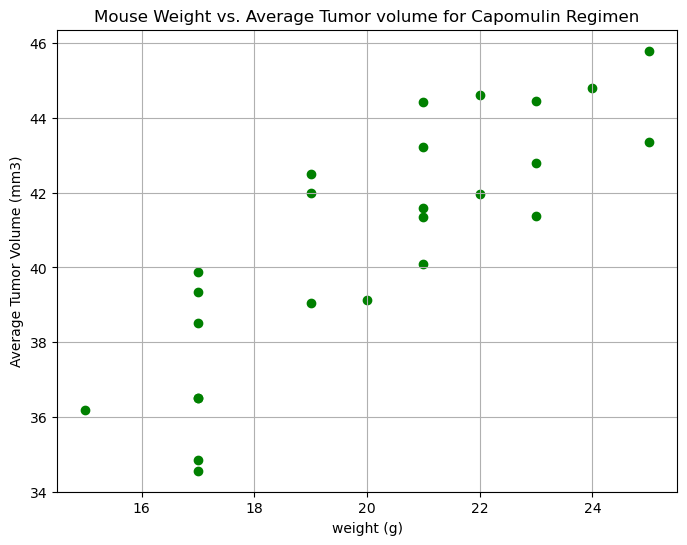

In [152]:
## Generate a scatter plot of mouse weight vs. the average observed tumor volume for the entire Capomulin regin
# Filter the data for Capomulin
sorted_cap_data = mousestudy_df[mousestudy_df["Drug Regimen"] == "Capomulin"]

#
average_tumor_volume = sorted_cap_data.groupby("Mouse ID").agg(
    AVG_Tumor_Volume=("Tumor Volume (mm3)", "mean"), Weight=("Weight (g)", "mean")).reset_index()
# Generate Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(average_tumor_volume["Weight"], average_tumor_volume["AVG_Tumor_Volume"], color="green")
plt.title("Mouse Weight vs. Average Tumor volume for Capomulin Regimen")
plt.xlabel("weight (g)")
plt.ylabel("Average Tumor Volume (mm3)")
plt.grid(True)
plt.show()
                                              

## Correlation and Regression

Pearson correlation coefficient: 0.84


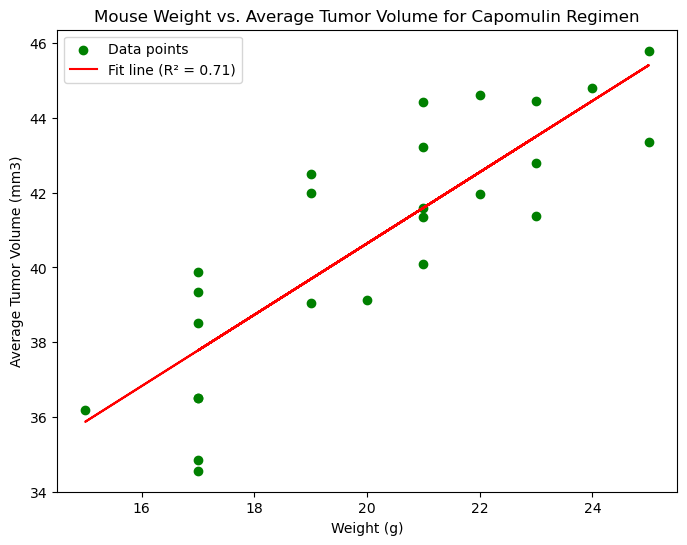

In [159]:
# Calculate the correlation coefficient and a linear regression model
# for mouse weight and average observed tumor volume for the entire Capomulin regimen
# Reference: https://stackoverflow.com/questions/63902183/how-do-i-plot-a-beautiful-scatter-plot-with-linear-regression



# Filter the data for the Capomulin regimen
capomulin_data = mousestudy_df[mousestudy_df["Drug Regimen"] == "Capomulin"]

# Calculate the average tumor volume and weight for each mouse
average_data = capomulin_data.groupby("Mouse ID").agg(
    Avg_Tumor_Volume=("Tumor Volume (mm3)", "mean"),
    Avg_Weight=("Weight (g)", "mean")
).reset_index()

# Compute the Pearson correlation coefficient
correlation = average_data["Avg_Weight"].corr(average_data["Avg_Tumor_Volume"])
print(f"Pearson correlation coefficient: {correlation:.2f}")

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(
    average_data["Avg_Weight"], average_data["Avg_Tumor_Volume"]
)

# Visualize the results
plt.figure(figsize=(8, 6))
plt.scatter(average_data["Avg_Weight"], average_data["Avg_Tumor_Volume"], color="green", label="Data points")
plt.plot(
    average_data["Avg_Weight"],
    intercept + slope * average_data["Avg_Weight"],
    color="red",
    label=f"Fit line (R² = {r_value**2:.2f})"
)
plt.title("Mouse Weight vs. Average Tumor Volume for Capomulin Regimen")
plt.xlabel("Weight (g)")
plt.ylabel("Average Tumor Volume (mm3)")
plt.legend()
plt.show()
plt.show()